# NB01: 성남시 행정경계 추출 및 행정동코드 매핑

**목적**: 전국 행정동 경계 shapefile에서 성남시 50개 동을 추출하고, CSV 데이터와 조인 가능한 행정동코드 crosswalk 생성

**입력**: `00_data/BND_ADM_DONG_PG/BND_ADM_DONG_PG.shp` (EPSG:5179, 전국 3,559개 동)  
**출력**: `processed/seongnam_boundary.gpkg` (성남시 50개 동, EPSG:4326, 행정동코드 매핑 포함)

In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam")
RAW = BASE / "00_data"
OUT = BASE / "processed"

## 1. 성남시 행정동 경계 추출

shapefile의 통계청코드 체계:
- `31021xxx` = 수정구, `31022xxx` = 중원구, `31023xxx` = 분당구

In [2]:
# 전국 행정동 경계 로드 & 성남시만 필터링
gdf_all = gpd.read_file(RAW / "BND_ADM_DONG_PG" / "BND_ADM_DONG_PG.shp")
print(f"전국 행정동 수: {len(gdf_all)}, CRS: {gdf_all.crs}")

SEONGNAM_PREFIXES = ("31021", "31022", "31023")
seongnam = gdf_all[gdf_all["ADM_CD"].astype(str).str[:5].isin(SEONGNAM_PREFIXES)].copy()
print(f"성남시 행정동 수: {len(seongnam)}")

# 구 이름 매핑
GU_MAP = {"31021": "수정구", "31022": "중원구", "31023": "분당구"}
seongnam["GU_NM"] = seongnam["ADM_CD"].astype(str).str[:5].map(GU_MAP)
seongnam[["ADM_CD", "GU_NM", "ADM_NM"]].sort_values("ADM_CD").head(10)

전국 행정동 수: 3559, CRS: EPSG:5179
성남시 행정동 수: 50


,ADM_CD,GU_NM,ADM_NM
1239,31021510,수정구,신흥1동
1240,31021520,수정구,신흥2동
1241,31021530,수정구,신흥3동
1242,31021540,수정구,태평1동
1243,31021550,수정구,태평2동
1244,31021560,수정구,태평3동
1245,31021570,수정구,태평4동
1246,31021580,수정구,수진1동
1247,31021590,수정구,수진2동
1248,31021600,수정구,단대동


## 2. 행정동코드 Crosswalk 생성

CSV 데이터의 행정동코드 체계: `41131xxx`(수정구), `41133xxx`(중원구), `41135xxx`(분당구)  
동 이름(ADM_NM)으로 매칭하여 crosswalk 테이블 생성

In [3]:
# CSV 행정동코드 추출 (유동인구 데이터에서)
import glob

fp_files = sorted(glob.glob(str(RAW / "민간데이터" / "T22*" / "T22" / "*.csv")))
df_fp = pd.read_csv(fp_files[0])
csv_codes = (
    df_fp[["ADMI_CD", "ADMI_NM"]]
    .drop_duplicates()
    .sort_values("ADMI_CD")
    .reset_index(drop=True)
)
csv_codes.columns = ["CSV_ADMI_CD", "DONG_NM"]
print(f"CSV 행정동 수: {len(csv_codes)}")

# shapefile 측 동 이름
shp_codes = (
    seongnam[["ADM_CD", "ADM_NM", "GU_NM"]]
    .sort_values("ADM_CD")
    .reset_index(drop=True)
    .rename(columns={"ADM_CD": "SHP_ADM_CD", "ADM_NM": "DONG_NM"})
)

# 동 이름으로 조인
crosswalk = shp_codes.merge(csv_codes, on="DONG_NM", how="outer", indicator=True)
print(f"\n매칭 결과:")
print(crosswalk["_merge"].value_counts())

# 매칭 안 된 항목 확인
unmatched = crosswalk[crosswalk["_merge"] != "both"]
if len(unmatched) > 0:
    print(f"\n매칭 실패 ({len(unmatched)}건):")
    print(unmatched[["DONG_NM", "SHP_ADM_CD", "CSV_ADMI_CD", "_merge"]])
else:
    print("\n모든 동이 정상 매칭됨!")

CSV 행정동 수: 50



매칭 결과:
_merge
both          50
left_only      0
right_only     0
Name: count, dtype: int64

모든 동이 정상 매칭됨!


In [4]:
# 매칭 안 된 항목이 있으면 수동 매핑으로 해결
# (shapefile과 CSV에서 동 이름이 다르거나, 한쪽에만 존재하는 경우)
MANUAL_MAP = {
    # SHP_ADM_CD -> CSV_ADMI_CD (필요시 여기에 수동 매핑 추가)
    # 예: "31023780": 41135545,  # 정자동 (shapefile) -> 정자동 (CSV)
}

# 정상 매칭된 것만 최종 crosswalk
matched = crosswalk[crosswalk["_merge"] == "both"].drop(columns="_merge").copy()
matched["CSV_ADMI_CD"] = matched["CSV_ADMI_CD"].astype(int)
print(f"최종 crosswalk: {len(matched)}건")
matched.head(10)

최종 crosswalk: 50건


,SHP_ADM_CD,DONG_NM,GU_NM,CSV_ADMI_CD
0,31021650,고등동,수정구,41131640
1,31023720,구미1동,분당구,41135665
2,31023670,구미동,분당구,41135670
3,31023710,금곡동,분당구,41135662
4,31022530,금광1동,중원구,41133530
5,31022540,금광2동,중원구,41133540
6,31021600,단대동,수정구,41131590
7,31022610,도촌동,중원구,41133670
8,31023760,백현동,분당구,41135657
9,31021670,복정동,수정구,41131620


## 3. Crosswalk을 경계 GeoDataFrame에 병합 & CRS 변환

In [5]:
# crosswalk을 seongnam GeoDataFrame에 병합
seongnam = seongnam.rename(columns={"ADM_CD": "SHP_ADM_CD"})
seongnam = seongnam.merge(
    matched[["SHP_ADM_CD", "CSV_ADMI_CD"]],
    on="SHP_ADM_CD",
    how="left",
)

# WGS84 변환 (Tableau & 웹 지도용)
seongnam_4326 = seongnam.to_crs(epsg=4326)
print(f"CRS 변환 완료: {seongnam_4326.crs}")
print(f"컬럼: {seongnam_4326.columns.tolist()}")
seongnam_4326[["SHP_ADM_CD", "CSV_ADMI_CD", "GU_NM", "ADM_NM"]].head()

CRS 변환 완료: EPSG:4326
컬럼: ['BASE_DATE', 'SHP_ADM_CD', 'ADM_NM', 'geometry', 'GU_NM', 'CSV_ADMI_CD']


,SHP_ADM_CD,CSV_ADMI_CD,GU_NM,ADM_NM
0,31021510,41131510,수정구,신흥1동
1,31021520,41131520,수정구,신흥2동
2,31021530,41131530,수정구,신흥3동
3,31021540,41131540,수정구,태평1동
4,31021550,41131550,수정구,태평2동


## 4. 성남시 전체 경계(Dissolved) 생성 + Bounding Box 계산

In [6]:
# 성남시 전체 경계 (동 경계 합치기)
city_boundary = seongnam_4326.dissolve()
city_boundary["NAME"] = "성남시"
print(f"성남시 전체 경계 생성 (1 polygon)")

# Bounding box (EPSG:4326 / EPSG:5179 양쪽 계산)
bounds_4326 = seongnam_4326.total_bounds  # (minx, miny, maxx, maxy)
bounds_5179 = seongnam.total_bounds
print(f"\nBounds (EPSG:4326): lon {bounds_4326[0]:.4f}~{bounds_4326[2]:.4f}, lat {bounds_4326[1]:.4f}~{bounds_4326[3]:.4f}")
print(f"Bounds (EPSG:5179): x {bounds_5179[0]:.0f}~{bounds_5179[2]:.0f}, y {bounds_5179[1]:.0f}~{bounds_5179[3]:.0f}")
print(f"\n→ NB02에서 건물 shapefile 읽을 때 bbox 필터에 사용: bbox=({bounds_5179[0]:.0f}, {bounds_5179[1]:.0f}, {bounds_5179[2]:.0f}, {bounds_5179[3]:.0f})")

성남시 전체 경계 생성 (1 polygon)

Bounds (EPSG:4326): lon 127.0277~127.1958, lat 37.3334~37.4748
Bounds (EPSG:5179): x 958183~973093, y 1926110~1941780

→ NB02에서 건물 shapefile 읽을 때 bbox 필터에 사용: bbox=(958183, 1926110, 973093, 1941780)


## 5. 시각적 검증

C:\Users\jimin\AppData\Local\Temp\ipykernel_36880\3063391924.py:18: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[0].legend(fontsize=10)
C:\Users\jimin\AppData\Local\Temp\ipykernel_36880\3063391924.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=10)


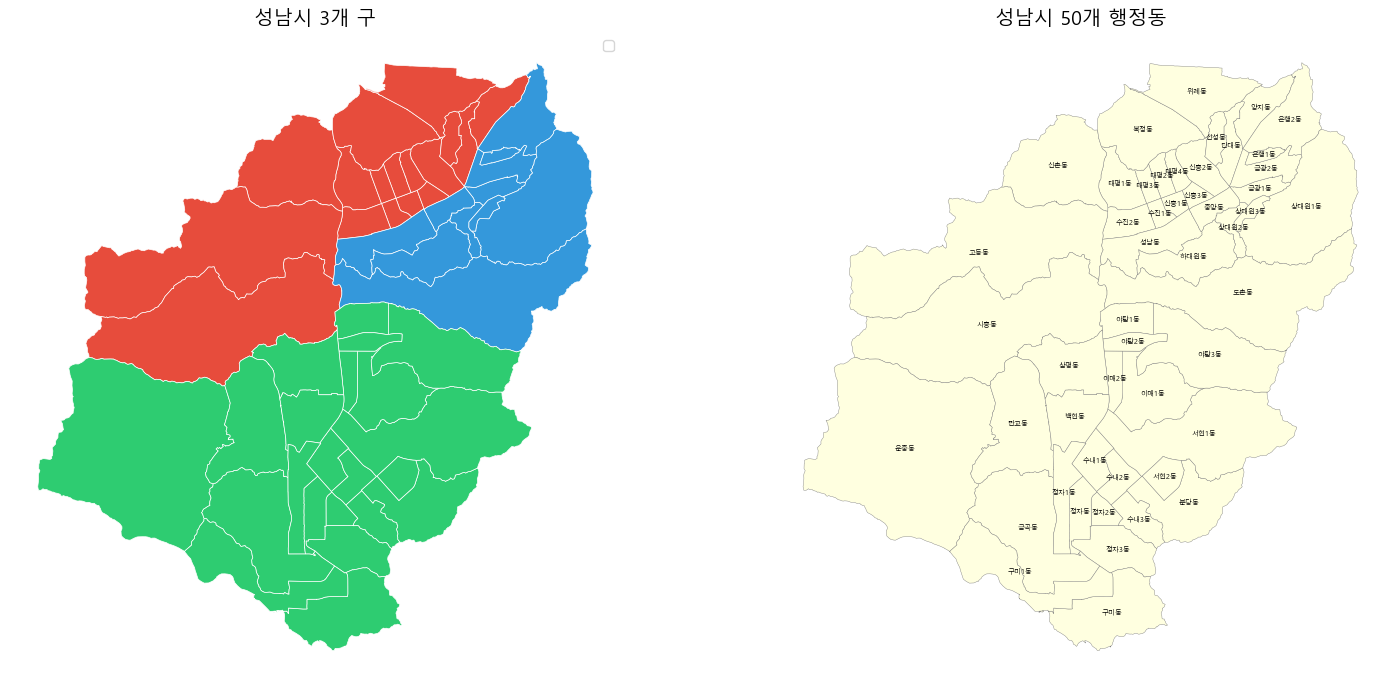

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 구별 색상
colors = {"수정구": "#e74c3c", "중원구": "#3498db", "분당구": "#2ecc71"}

# 왼쪽: 구별 색상
for gu, color in colors.items():
    seongnam_4326[seongnam_4326["GU_NM"] == gu].plot(
        ax=axes[0], color=color, edgecolor="white", linewidth=0.5, label=gu
    )
axes[0].legend(fontsize=10)
axes[0].set_title("성남시 3개 구", fontsize=14)
axes[0].set_axis_off()

# 오른쪽: 동별 + 라벨
seongnam_4326.plot(ax=axes[1], edgecolor="gray", linewidth=0.3, color="lightyellow")
for _, row in seongnam_4326.iterrows():
    centroid = row.geometry.centroid
    axes[1].annotate(
        row["ADM_NM"], xy=(centroid.x, centroid.y),
        fontsize=5, ha="center", va="center"
    )
axes[1].set_title("성남시 50개 행정동", fontsize=14)
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

## 6. 저장

In [8]:
# 행정동 경계 (EPSG:4326, CSV 행정동코드 포함)
seongnam_4326.to_file(OUT / "seongnam_boundary.gpkg", layer="dong", driver="GPKG")

# 성남시 전체 경계 (dissolved)
city_boundary.to_file(OUT / "seongnam_boundary.gpkg", layer="city", driver="GPKG")

# 행정동 경계 (EPSG:5179, 거리 계산용)
seongnam.to_file(OUT / "seongnam_boundary.gpkg", layer="dong_5179", driver="GPKG")

# Crosswalk CSV (다른 노트북에서 참조용)
crosswalk_df = matched[["SHP_ADM_CD", "CSV_ADMI_CD", "GU_NM", "DONG_NM"]].copy()
crosswalk_df.to_csv(OUT / "admin_code_crosswalk.csv", index=False, encoding="utf-8-sig")

print("저장 완료:")
print(f"  - {OUT / 'seongnam_boundary.gpkg'} (3 layers: dong, city, dong_5179)")
print(f"  - {OUT / 'admin_code_crosswalk.csv'}")
print(f"\n성남시 Bounds (EPSG:5179) for NB02 bbox filter:")
print(f"  bbox=({bounds_5179[0]:.0f}, {bounds_5179[1]:.0f}, {bounds_5179[2]:.0f}, {bounds_5179[3]:.0f})")

저장 완료:
  - C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\seongnam_boundary.gpkg (3 layers: dong, city, dong_5179)
  - C:\Users\jimin\Desktop\1_BITAmin_16기\1_Seongnam\processed\admin_code_crosswalk.csv

성남시 Bounds (EPSG:5179) for NB02 bbox filter:
  bbox=(958183, 1926110, 973093, 1941780)
